In [ ]:
# Install/Upgrade the libraries

!pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124

!pip install -q --upgrade transformers==4.48.3 datasets==3.2.0 diffusers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 71.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 95.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 91.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Imports

import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio

In [ ]:
# Connecting to hugging face by API key

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
# Sentiment Analysis

classifier = pipeline("sentiment-analysis", device="cuda")
result = classifier("I'm super excited to be on the way to LLM mastery!")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9993460774421692}]


In [ ]:
# Named Entity Recognition

ner = pipeline("ner", grouped_entities=True, device="cuda")
result = ner("Barack Obama was the 44th president of the United States.")
print(result)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'entity_group': 'PER', 'score': np.float32(0.99918306), 'word': 'Barack Obama', 'start': 0, 'end': 12}, {'entity_group': 'LOC', 'score': np.float32(0.9986908), 'word': 'United States', 'start': 43, 'end': 56}]


/usr/local/lib/python3.11/dist-packages/transformers/pipelines/token_classification.py:170: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(


In [ ]:
# Question Answering with Context

question_answerer = pipeline("question-answering", device="cuda")
result = question_answerer(question="Who was the 44th president of the United States?", context="Barack Obama was the 44th president of the United States.")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'score': 0.9889456033706665, 'start': 0, 'end': 12, 'answer': 'Barack Obama'}


In [ ]:
# Text Summarization

summarizer = pipeline("summarization", device="cuda")
text = """The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""
summary = summarizer(text, max_length=50, min_length=25, do_sample=False)
print(summary[0]['summary_text'])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


 The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .


In [ ]:
# Translation

translator = pipeline("translation_en_to_fr", device="cuda")
result = translator("The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.")
print(result[0]['translation_text'])

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


Les Data Scientists ont été vraiment étonnés par la puissance et la simplicité de l'API du pipeline HuggingFace.


In [ ]:
# Another translation, showing a model being specified
# All translation models are here: https://huggingface.co/models?pipeline_tag=translation&sort=trending

translator = pipeline("translation_en_to_hi", model="Helsinki-NLP/opus-mt-en-hi", device="cuda")
result = translator("The weather is nice today.")
print(result[0]['translation_text'])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda


मौसम आज अच्छा है.


In [ ]:
# Classification

classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("Hugging Face's Transformers library is amazing!", candidate_labels=["technology", "sports", "politics"])
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'sequence': "Hugging Face's Transformers library is amazing!", 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9493839740753174, 0.03225007280707359, 0.018365919589996338]}


In [ ]:
# Text Generation

generator = pipeline("text-generation", device="cuda")
result = generator("If there's one thing I want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


If there's one thing I want you to remember about using HuggingFace pipelines, it's that we get a lot of support from other developers in our pipeline. Even though our test-driven test framework is not entirely automated, it gives us a


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

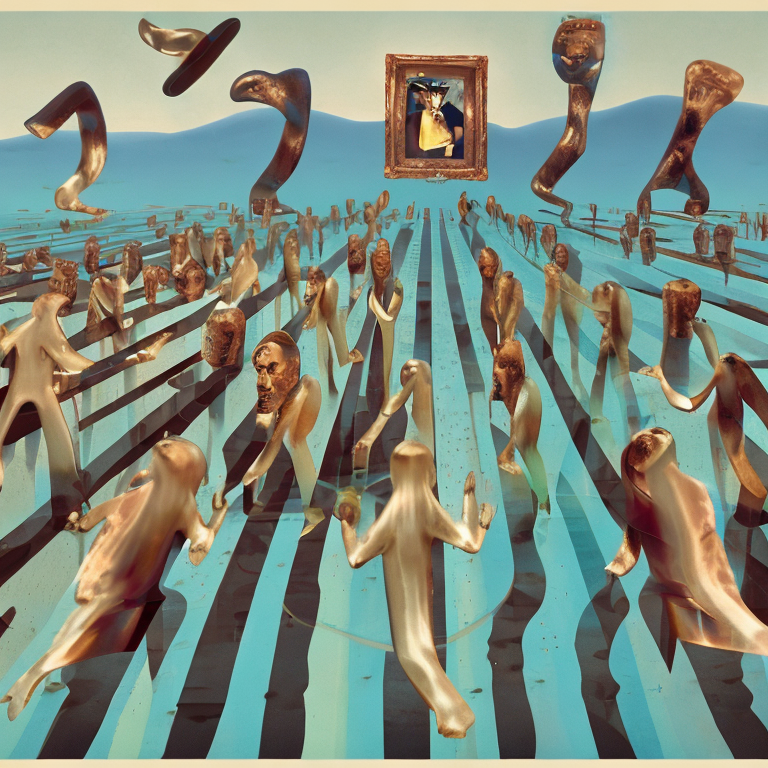

In [ ]:
# Image Generation

image_gen = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-2",
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
    ).to("cuda")

text = "A class of Data Scientists learning about AI, in the surreal style of Salvador Dali"
image = image_gen(prompt=text).images[0]
image

In [ ]:
# Audio Generation

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')

embeddings_dataset = load_dataset("Matthijs/cmu-arctic-xvectors", split="validation")
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)

speech = synthesiser("We don’t just work with data, we transform it into stories, insights, and smarter decisions for a better tomorrow", forward_params={"speaker_embeddings": speaker_embedding})

sf.write("speech.wav", speech["audio"], samplerate=speech["sampling_rate"])
Audio("speech.wav")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/585M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/232 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/585M [00:00<?, ?B/s]

spm_char.model:   0%|          | 0.00/238k [00:00<?, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/50.6M [00:00<?, ?B/s]

cmu-arctic-xvectors.py: 0.00B [00:00, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/21.3M [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/7931 [00:00<?, ? examples/s]

## Tokenizers

In [ ]:
!pip install -q transformers

In [ ]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer

In [ ]:
hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3.1-8B', trust_remote_code=True)

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

In [ ]:
text = "I am excited to show Tokenizers in action to my LLM engineers"
tokens = tokenizer.encode(text)
tokens

[128000,
 40,
 1097,
 12304,
 311,
 1501,
 9857,
 12509,
 304,
 1957,
 311,
 856,
 445,
 11237,
 25175]

In [ ]:
len(tokens)

15

In [ ]:
tokenizer.decode(tokens)

'<|begin_of_text|>I am excited to show Tokenizers in action to my LLM engineers'

In [ ]:
tokenizer.batch_decode(tokens)

['<|begin_of_text|>',
 'I',
 ' am',
 ' excited',
 ' to',
 ' show',
 ' Token',
 'izers',
 ' in',
 ' action',
 ' to',
 ' my',
 ' L',
 'LM',
 ' engineers']

In [ ]:
# tokenizer.vocab
tokenizer.get_added_vocab()

{'<|begin_of_text|>': 128000,
 '<|end_of_text|>': 128001,
 '<|reserved_special_token_0|>': 128002,
 '<|reserved_special_token_1|>': 128003,
 '<|finetune_right_pad_id|>': 128004,
 '<|reserved_special_token_2|>': 128005,
 '<|start_header_id|>': 128006,
 '<|end_header_id|>': 128007,
 '<|eom_id|>': 128008,
 '<|eot_id|>': 128009,
 '<|python_tag|>': 128010,
 '<|reserved_special_token_3|>': 128011,
 '<|reserved_special_token_4|>': 128012,
 '<|reserved_special_token_5|>': 128013,
 '<|reserved_special_token_6|>': 128014,
 '<|reserved_special_token_7|>': 128015,
 '<|reserved_special_token_8|>': 128016,
 '<|reserved_special_token_9|>': 128017,
 '<|reserved_special_token_10|>': 128018,
 '<|reserved_special_token_11|>': 128019,
 '<|reserved_special_token_12|>': 128020,
 '<|reserved_special_token_13|>': 128021,
 '<|reserved_special_token_14|>': 128022,
 '<|reserved_special_token_15|>': 128023,
 '<|reserved_special_token_16|>': 128024,
 '<|reserved_special_token_17|>': 128025,
 '<|reserved_special_to

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('meta-llama/Meta-Llama-3.1-8B-Instruct', trust_remote_code=True)

In [ ]:
messages = [
    {"role": "system", "content": "You are a helpful assistant"},
    {"role": "user", "content": "Tell a light-hearted joke for a room of Data Scientists"}
  ]

prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
print(prompt)

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>

Tell a light-hearted joke for a room of Data Scientists<|eot_id|><|start_header_id|>assistant<|end_header_id|>




## Trying new models

We will now work with 3 models:

Phi3 from Microsoft Qwen2 from Alibaba Cloud Starcoder2 from BigCode (ServiceNow + HuggingFace + NVidia)

In [ ]:
PHI3_MODEL_NAME = "microsoft/Phi-3-mini-4k-instruct"
QWEN2_MODEL_NAME = "Qwen/Qwen2-7B-Instruct"
STARCODER2_MODEL_NAME = "bigcode/starcoder2-3b"

In [ ]:
phi3_tokenizer = AutoTokenizer.from_pretrained(PHI3_MODEL_NAME)

text = "I am excited to show Tokenizers in action to my LLM engineers"
print(tokenizer.encode(text))
print()
tokens = phi3_tokenizer.encode(text)
print(tokens)
print(phi3_tokenizer.batch_decode(tokens))

[128000, 40, 1097, 12304, 311, 1501, 9857, 12509, 304, 1957, 311, 856, 445, 11237, 25175]

[306, 626, 24173, 304, 1510, 25159, 19427, 297, 3158, 304, 590, 365, 26369, 6012, 414]
['I', 'am', 'excited', 'to', 'show', 'Token', 'izers', 'in', 'action', 'to', 'my', 'L', 'LM', 'engine', 'ers']


In [ ]:
print(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
print()
print(phi3_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>

Tell a light-hearted joke for a room of Data Scientists<|eot_id|><|start_header_id|>assistant<|end_header_id|>



<|system|>
You are a helpful assistant<|end|>
<|user|>
Tell a light-hearted joke for a room of Data Scientists<|end|>
<|assistant|>



In [ ]:
qwen2_tokenizer = AutoTokenizer.from_pretrained(QWEN2_MODEL_NAME)

text = "I am excited to show Tokenizers in action to my LLM engineers"
print(tokenizer.encode(text))
print()
print(phi3_tokenizer.encode(text))
print()
print(qwen2_tokenizer.encode(text))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

[128000, 40, 1097, 12304, 311, 1501, 9857, 12509, 304, 1957, 311, 856, 445, 11237, 25175]

[306, 626, 24173, 304, 1510, 25159, 19427, 297, 3158, 304, 590, 365, 26369, 6012, 414]

[40, 1079, 12035, 311, 1473, 9660, 12230, 304, 1917, 311, 847, 444, 10994, 24198]


In [ ]:
print(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
print()
print(phi3_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))
print()
print(qwen2_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>

Tell a light-hearted joke for a room of Data Scientists<|eot_id|><|start_header_id|>assistant<|end_header_id|>



<|system|>
You are a helpful assistant<|end|>
<|user|>
Tell a light-hearted joke for a room of Data Scientists<|end|>
<|assistant|>


<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Tell a light-hearted joke for a room of Data Scientists<|im_end|>
<|im_start|>assistant



In [ ]:
starcoder2_tokenizer = AutoTokenizer.from_pretrained(STARCODER2_MODEL_NAME, trust_remote_code=True)
code = """
def hello_world(person):
  print("Hello", person)
"""
tokens = starcoder2_tokenizer.encode(code)
for token in tokens:
  print(f"{token}={starcoder2_tokenizer.decode(token)}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

222=

610=def
17966= hello
100=_
5879=world
45=(
6427=person
731=):
353=
 
1489= print
459=("
8302=Hello
411=",
4944= person
46=)
222=



## Models & Quantizing LLM

In [ ]:
!pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q requests bitsandbytes==0.46.0 transformers==4.48.3 accelerate==1.3.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.6/336.6 kB 30.8 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch
import gc

In [ ]:
hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [ ]:
# instruct models

LLAMA = "meta-llama/Meta-Llama-3.1-8B-Instruct"
PHI3 = "microsoft/Phi-3-mini-4k-instruct"
GEMMA2 = "google/gemma-2-2b-it"
QWEN2 = "Qwen/Qwen2-7B-Instruct"
MIXTRAL = "mistralai/Mixtral-8x7B-Instruct-v0.1"

In [ ]:
messages = [
    {"role": "system", "content": "You are a helpful assistant"},
    {"role": "user", "content": "Tell a light-hearted joke for a room of Data Scientists"}
  ]

In [ ]:
# Quantization Config - this allows us to load the model into memory and use less memory

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [ ]:
# Tokenizer

tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")

In [ ]:
# The model

model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quant_config)

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

In [ ]:
memory = model.get_memory_footprint() / 1e6
print(f"Memory footprint: {memory:,.1f} MB")

Memory footprint: 5,591.5 MB


In [ ]:
# Execute this cell and look at what gets printed; investigate the layers

model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((409

In [ ]:
# OK, with that, now let's run the model!

outputs = model.generate(inputs, max_new_tokens=80)
print(tokenizer.decode(outputs[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are a helpful assistant<|eot_id|><|start_header_id|>user<|end_header_id|>

Tell a light-hearted joke for a room of Data Scientists<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Why did the linear regression model go to therapy?

Because it was struggling to cope with its overfitting issues and had a lot of 'noise' in its relationships.<|eot_id|>


In [ ]:
# Clean up memory
# Thank you Kuan L. for helping me get this to properly free up memory!
# If you select "Show Resources" on the top right to see GPU memory, it might not drop down right away
# But it does seem that the memory is available for use by new models in the later code.

del model, inputs, tokenizer, outputs
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# Wrapping everything in a function - and adding Streaming and generation prompts

def generate(model, messages):
  tokenizer = AutoTokenizer.from_pretrained(model)
  tokenizer.pad_token = tokenizer.eos_token
  inputs = tokenizer.apply_chat_template(messages, return_tensors="pt", add_generation_prompt=True).to("cuda")
  streamer = TextStreamer(tokenizer)
  model = AutoModelForCausalLM.from_pretrained(model, device_map="auto", quantization_config=quant_config)
  outputs = model.generate(inputs, max_new_tokens=80, streamer=streamer)
  del model, inputs, tokenizer, outputs, streamer
  gc.collect()
  torch.cuda.empty_cache()

In [ ]:
generate(PHI3, messages)

config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.67G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

<|system|> You are a helpful assistant<|end|><|user|> Tell a light-hearted joke for a room of Data Scientists<|end|><|assistant|> Why did the data scientist break up with the algorithm?

Because it was always calculating the wrong variables in their relationship!<|end|>


In [ ]:
generate(QWEN2, messages)

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/3.95G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/3.86G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/3.56G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

<|im_start|>system
You are a helpful assistant<|im_end|>
<|im_start|>user
Tell a light-hearted joke for a room of Data Scientists<|im_end|>
<|im_start|>assistant
Why did the data scientist break up with the statistician?

Because he needed a model that could predict love accurately, and nothing statistical could guarantee that!<|im_end|>


In [ ]:
messages = [
    {"role": "user", "content": "Tell a light-hearted joke for a room of Data Scientists"}
  ]
generate(GEMMA2, messages)

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/241M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

<bos><start_of_turn>user
Tell a light-hearted joke for a room of Data Scientists<end_of_turn>
<start_of_turn>model
Why did the data scientist break up with the statistician? 

Because they had too many differences! 😂 

---

Let me know if you'd like to hear another joke! 😊 
<end_of_turn>


# Create meeting minutes from an Audio file

The goal of this product is to use the Audio to generate meeting minutes, including actions.

For this project, you can either use the Denver meeting minutes, or you can record something of your own!

In [1]:
!pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
!pip install -q requests bitsandbytes==0.46.0 transformers==4.48.3 accelerate==1.3.0 openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.3/908.3 MB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 111.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 113.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# imports

import os
import requests
from IPython.display import Markdown, display, update_display
from openai import OpenAI
from google.colab import drive
from huggingface_hub import login
from google.colab import userdata
from transformers import AutoTokenizer, AutoModelForCausalLM, TextStreamer, BitsAndBytesConfig
import torch

In [3]:
# Constants

AUDIO_MODEL = "whisper-1"
LLAMA = "meta-llama/Meta-Llama-3.1-8B-Instruct"

In [4]:
audio_filename = "/content/denver_extract.mp3"

In [5]:
# Sign in to HuggingFace Hub

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [6]:
# Sign in to OpenAI using Secrets in Colab

openai_api_key = userdata.get('OPENAI_API_KEY')
openai = OpenAI(api_key=openai_api_key)

In [7]:
# Use the Whisper OpenAI model to convert the Audio to Text
# If you'd prefer to use an Open Source model, class student Your self has contributed an open source version
# which I've added to the bottom of this colab

audio_file = open(audio_filename, "rb")
transcription = openai.audio.transcriptions.create(model=AUDIO_MODEL, file=audio_file, response_format="text")
print(transcription)

and kind of the confluence of this whole idea of the confluence week, the merging of two rivers and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and it's a very big issue. So that is the reason that the back of the logo is considered water. So let me see the creation of the logo here. So that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism and you'll hear a little bit more about our confluence week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous People's Day. So thank you. Thank you so much and thanks for your leadership. All right. Welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of the United Sta

In [8]:
system_message = "You are an assistant that produces minutes of meetings from transcripts, with summary, key discussion points, takeaways and action items with owners, in markdown."
user_prompt = f"Below is an extract transcript of a Denver council meeting. Please write minutes in markdown, including a summary with attendees, location and date; discussion points; takeaways; and action items with owners.\n{transcription}"

messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": user_prompt}
  ]

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
)

In [10]:
tokenizer = AutoTokenizer.from_pretrained(LLAMA)
tokenizer.pad_token = tokenizer.eos_token
inputs = tokenizer.apply_chat_template(messages, return_tensors="pt").to("cuda")
streamer = TextStreamer(tokenizer)
model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="auto", quantization_config=quant_config)
outputs = model.generate(inputs, max_new_tokens=2000, streamer=streamer)

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are an assistant that produces minutes of meetings from transcripts, with summary, key discussion points, takeaways and action items with owners, in markdown.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting. Please write minutes in markdown, including a summary with attendees, location and date; discussion points; takeaways; and action items with owners.
and kind of the confluence of this whole idea of the confluence week, the merging of two rivers and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and it's a very big issue. So that is the reason that the back of the logo is considered water. So let me see the creation of the logo here. So that basically kind of sums up the reason behind the logo and all the meanings b

In [ ]:
# Code used for CPU run
# # Load tokenizer
# tokenizer = AutoTokenizer.from_pretrained(LLAMA)
# tokenizer.pad_token = tokenizer.eos_token

# # Prepare chat-style input (no need to move to CUDA)
# inputs = tokenizer.apply_chat_template(messages, return_tensors="pt")

# # Streamer for printing output live
# streamer = TextStreamer(tokenizer)

# # Load the model on CPU (no quantization)
# model = AutoModelForCausalLM.from_pretrained(LLAMA, device_map="cpu")

# # Generate text
# outputs = model.generate(
#     inputs,
#     max_new_tokens=2000,
#     streamer=streamer
# )

In [11]:
response = tokenizer.decode(outputs[0])

In [12]:
display(Markdown(response))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024

You are an assistant that produces minutes of meetings from transcripts, with summary, key discussion points, takeaways and action items with owners, in markdown.<|eot_id|><|start_header_id|>user<|end_header_id|>

Below is an extract transcript of a Denver council meeting. Please write minutes in markdown, including a summary with attendees, location and date; discussion points; takeaways; and action items with owners.
and kind of the confluence of this whole idea of the confluence week, the merging of two rivers and as we've kind of seen recently in politics and in the world, there's a lot of situations where water is very important right now and it's a very big issue. So that is the reason that the back of the logo is considered water. So let me see the creation of the logo here. So that basically kind of sums up the reason behind the logo and all the meanings behind the symbolism and you'll hear a little bit more about our confluence week is basically highlighting all of these indigenous events and things that are happening around Denver so that we can kind of bring more people together and kind of share this whole idea of Indigenous People's Day. So thank you. Thank you so much and thanks for your leadership. All right. Welcome to the Denver City Council meeting of Monday, October 9th. Please rise with the Pledge of Allegiance by Councilman Lopez. I pledge allegiance to the flag of the United States of America, and to the republic for which it stands, one nation, under God, indivisible, with liberty and justice for all. All right. Thank you, Councilman Lopez. Madam Secretary, roll call. Clerk. Here. Espinosa. Here. Flynn. Here. Gilmour. Here. Here. Cashman. Here. Kenneche. Here. Lopez. Here. New. Here. Ortega. Here. Sussman. Here. Mr. President. Here. 11 present. 11 members present. We do have a quorum. Approval of the minutes. Seeing none, minutes of October 2nd stand approved. Council announcements. Are there any announcements by members of Council? Councilman Clark. Thank you, Mr. President. I just wanted to invite everyone down to the first ever Halloween parade on Broadway in Lucky District 7. It will happen on Saturday, October 21st at 6 o'clock p.m. It will move along Broadway from 3rd to Alameda. It's going to be a fun, family-friendly event. Everyone's invited to come down, wear a costume. There will be candy for the kids and there are tiki zombies and 29 hearses and all kinds of fun and funky stuff on the fun and funky part of Broadway. So please join us October 21st at 6 o'clock for the Broadway Halloween parade. Thank you, Mr. President. All right. Thank you, Councilman Clark. I will be there. All right. Presentations. Madam Secretary, do we have any presentations? None, Mr. President. Communications. Do we have any communications? None, Mr. President. We do have one proclamation this evening. Proclamation 1127, an observance of the annual Indigenous Peoples Day in the City and County of Denver. Councilman Lopez, will you please read it? Thank you, Mr. President, with pride. Proclamation number 17, well, let me just say this differently. Proclamation number 1127, series of 2017, an observance of the second annual Indigenous Peoples Day in the City and County of Denver. Whereas the Council of the City and County of Denver recognizes that the Indigenous Peoples have lived and flourished on the lands known as the Americas since time immemorial and that Denver and the surrounding communities are built upon the ancestral homelands of numerous Indigenous tribes, which include the Southern Ute, the Ute Mountain, Ute tribes of Colorado. And whereas the tribal homelands and seasonal encampments of the Arapaho and Cheyenne people along the banks of the Cherry Creek and South Platte River confluence gave bearing to the future settlements that would become the birthplace of the Mile High City. And whereas Colorado encompasses the ancestral homelands of 48 tribes and the City and County of Denver and surrounding communities are home to the descendants of approximately 100 tribal nations. And whereas on October 3, 2016, the City and County of Denver unanimously passed Council Bill 801, series of 2016, officially designating the second Monday of October of each year as Indigenous Peoples Day in Denver, Colorado. And whereas the Council of the City and County of Denver continues to recognize and value the vast contributions made to the community through Indigenous Peoples' knowledge, science, philosophy, arts, and culture. And through these contributions, the City of Denver has developed and thrived. Whereas the Indigenous community, especially youth, have made great efforts this year to draw attention to the contributions of Indigenous people, including Confluence Week, drawing record attendance to a National Indigenous Youth Leadership Conference, leading conversations on inclusion with their peers, and supporting increased Indigenous youth participation in science and engineering. Now, therefore, be it proclaimed by the Council of the City and County of Denver, Section 1, that the Council of the City and County of Denver celebrates and honors the cultural and foundational contributions of Indigenous people to our history, our past, our present, and future, and continues to promote the education of the Denver community about these historical and contemporary contributions of Indigenous people. Section 2, that the City and County of Denver, Colorado, does hereby observe October 9, 2017 as Indigenous Peoples Day. Section 3, that the Clerk of the City and County of Denver shall attest and affix the seal of the City and County of Denver to this proclamation, and that a copy be transmitted to the Denver American Indian Commission, the City and County of Denver School District No. 1, and the Colorado Commission on Indian Affairs. Thank you, Councilman Lopez. Your motion to adopt. Mr. President, I move that Proclamation No. 1127, Series of 2017, be adopted. All right. It has been moved and seconded. It comes from the members of Council. Councilman Lopez. Thank you, Mr. President. It gives me a lot of pleasure and pride to read this proclamation officially for the third time, but as Indigenous Peoples Day in Denver, officially for the second time. It's always awesome to be able to see not just this proclamation come by my desk, but to see so many different people from our community in our Council Chambers. It was a very beautiful piece of artwork that you presented to us earlier, and it is exactly the spirit that we drafted this proclamation and this actual, the ordinance that created Indigenous Peoples Day. And we sat down and wrote it, and as a community, we couldn't think of anything else to begin except for the confluence of the two rivers. And those confluence of the two rivers created such a great city. And we live in such an amazing city, and we're all proud of it, and sometimes we, and a lot of people from all over the country or all over the world are proud of it, and sometimes a little too proud of it is to tell them to go back home. But I'm kidding when I say that. But the really nice thing about this is that we are celebrating Indigenous Peoples Day out of pride for who we are, who we are as a city, and the contributions of Indigenous Peoples to the city, not out of spite, not out of a replacement of one culture over the other, or out of contempt or disrespect. I think of a quote that Cesar Chavez made very popular, and it stuck with me for a very long time, and any time I have the opportunity to speak in front of children, and especially children in our community, that they often second-guess themselves on where they're coming from, who they are. And I always say that it's very important to be proud of where you're from, and the quote that I use from Cesar Chavez is, you know, pride in one's own culture does not require contempt or disrespect of another. Right? And that's very important. It's very important for us to recognize that no matter who we are, where we come from in this society, your pride in your own culture does not require the contempt or disrespect of another. And man, what a year for that to just sit on our shoulders for a while, for us to think about. Right? And so I wanted to just thank you all. I think the commission, there's going to be a couple individuals that are going to come and speak. Thank you for your art, your lovely artwork, for us to see what's in your heart and what now has become, probably is going to be a very important symbol for the community. And also just for the work, the daily work, every single day. We still have a lot of brothers and sisters whose ancestors once lived in these lands freely now stand on street corners. Right? In poverty. Without access to services. Right? Without access to sobriety or even housing or jobs. And what a cruel way to pay back a culture that has paved the way for the city to be built upon its shores. Right? So we have a lot of work to do. And these kind of proclamations and this day is not a day off, it's a day on in Denver. Right? And addressing those critical issues. So I know that my colleagues are very supportive. I'm going to ask you to support this proclamation. As I know you always have done in the past. I'm very proud of today. Oh, and we made Time Magazine and Newsweek once again today. As being a leader in terms of the cities that are celebrating Indigenous Peoples Day. I wanted to make a point out of that. Thank you, Councilman Lopez, and thank you for sponsoring this. Councilman Martega? Mr. President, I want to ask that my name be added. I don't think I could add much more to what Councilman Lopez has shared with us. I want to thank him for bringing this forward. And really just appreciate all the contributions that our Native American community has contributed to this great city and great state. I worked in the Lieutenant Governor's Office when the Commission on Indian Affairs was and had the benefit of being able to go down to the Four Corners for a peace treaty signing ceremony between the Utes and the Comanches that had been sort of at odds with each other for about 100 years. And just being able to participate in that powwow was pretty awesome. And for those of you who continue to participate in the annual powwow, it's such a great opportunity for everybody else to enjoy so many of the contributions of the culture. I mean, to see that the dance continues to be carried on as well as the Native language from generation to generation is just so incredible because in so many cultures, you know, people have come here and assimilated to the norms here and they lose their language and lose a lot of the culture. And in the Native community, that hasn't happened. That has, you know, commitment to just passing that on from generation to generation is so important. And so I'm happy to be a co-sponsor of this tonight. Thank you. All right. Thank you, Councilwoman Ortega. Councilwoman Knitsch. Thank you very much. And I also want to thank my colleague for bringing this forward. And I just wanted to say a word to the artist about how beautiful and moving I thought this logo was and your description of it. And I think one of the things that is clear is, you know, the words sometimes don't convey the power of imagery or music or the other pieces that make up culture. And so I think the art is so important. And when you talked about water, I was also thinking about land. And I guess I just wanted to say thank you. Many of the Native American peoples of Colorado have been at the forefront, or actually nationally, of defending some of the public lands that have been protected over the last few years that are under attack right now. And they're places that the communities have fought to protect but that everyone gets to enjoy. And so I just think that it's an example of where cultural preservation intersects with environmental protection, with recreation, and all of the other ways that public lands are so important. And so I think I just wanted to say thank you for that because I think we have some very sacred places in our country that are at risk right now. And so as we celebrate, I appreciate that there's still a piece of resistance in here. And I think that I just want to mention a feeling of solidarity with that resistance. So thank you, and happy Confluence Week. Thank you, Councilwoman Kinneach. And seeing no other comments, I'll just say a couple. And in a time of such divisive ugliness and just despicable behavior from our leadership, the reason I'm so supportive of Indigenous Peoples' Day is because it means inclusivity. It means respecting all, respecting those who have been silenced on purpose for a long time and whose history has not been told. And so we celebrate inclusivity in the face of such evil times, honestly.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

**Minutes of the Denver City Council Meeting**
==============================================

**Date:** October 9th
**Location:** Denver City Council Chambers
**Attendees:**

* Councilman Lopez
* Councilman Clark
* Councilwoman Ortega
* Councilwoman Kinneche
* Councilman Martega
* Councilwoman Knitsch

**Summary:**
The Denver City Council meeting was held on October 9th to discuss and adopt Proclamation No. 1127, Series of 2017, an observance of the second annual Indigenous Peoples Day in the City and County of Denver. The proclamation highlights the cultural and foundational contributions of Indigenous people to the city's history, present, and future.

**Discussion Points:**

* The importance of Indigenous Peoples Day as a celebration of inclusivity and respect for all cultures.
* The significance of the confluence of the two rivers in the creation of the city of Denver.
* The contributions of Indigenous people to the city's history, including their knowledge, science, philosophy, arts, and culture.
* The need to address critical issues affecting Indigenous communities, such as poverty, lack of access to services, and housing.
* The importance of preserving public lands and cultural heritage.

**Takeaways:**

* The city of Denver recognizes and values the contributions of Indigenous people to its history and culture.
* The proclamation highlights the importance of inclusivity and respect for all cultures.
* The city of Denver is committed to addressing critical issues affecting Indigenous communities.

**Action Items:**

* Adopt Proclamation No. 1127, Series of 2017, an observance of the second annual Indigenous Peoples Day in the City and County of Denver.
* Continue to promote education and awareness about the historical and contemporary contributions of Indigenous people.
* Address critical issues affecting Indigenous communities, including poverty, lack of access to services, and housing.
* Preserve public lands and cultural heritage.

**Owners:**

* Councilman Lopez: Sponsor of the proclamation and leader of the Indigenous Peoples Day committee.
* Councilman Martega: Co-sponsor of the proclamation and advocate for Indigenous communities.
* Councilwoman Ortega: Supporter of the proclamation and advocate for Indigenous communities.
* Councilwoman Kinneche: Supporter of the proclamation and advocate for Indigenous communities.
* Councilwoman Knitsch: Supporter of the proclamation and advocate for Indigenous communities.<|eot_id|>